# **Imports**

In [6]:
import torch
import numpy as np
print("PyTorch Version:", torch.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch Version: 2.6.0+cu124


# **TASK 1.1**

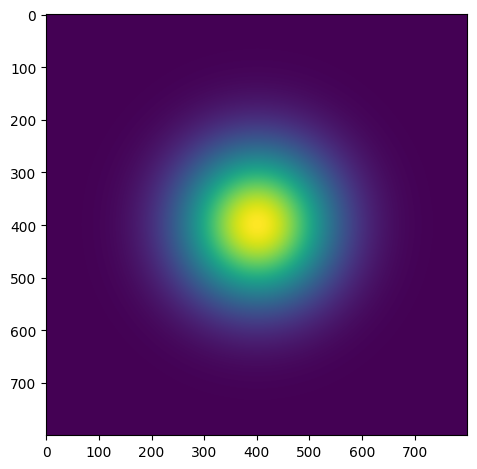

In [8]:
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)

# transfer to the GPU device
x = x.to(device)
y = y.to(device)

# Compute Gaussian
z = torch.exp(-(x**2+y**2)/2.0)

#plot
import matplotlib.pyplot as plt
plt.imshow(z.cpu().numpy())#Updated!
plt.tight_layout()
plt.show()

# **TASK 1.2**

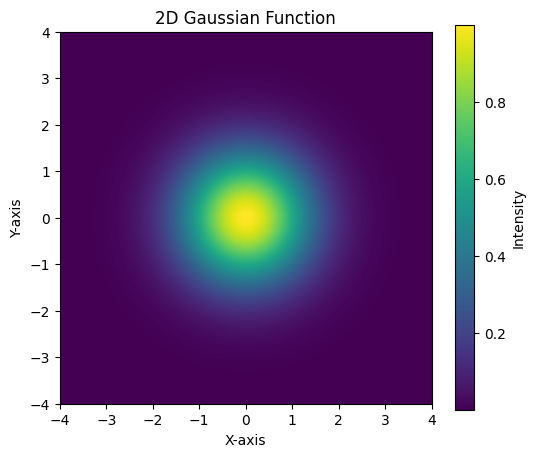

Using: cpu


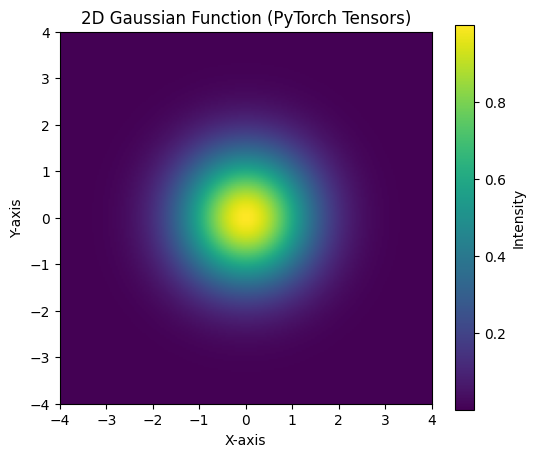

In [12]:
#Prompt used: Generate a Python script to plot a 2D Gaussian function using Numpy and Matplotlib with this function r = x^2 + y^2
#Using np
import numpy as np
import matplotlib.pyplot as plt

# Define grid
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)

# Define 2D Gaussian function
sigma = 1.0  # standard deviation
Z = np.exp(- (X**2 + Y**2) / (2 * sigma**2))

# Plot
plt.figure(figsize=(6,5))
plt.imshow(Z, extent=(-4,4,-4,4), origin='lower', cmap='viridis')
plt.colorbar(label="Intensity")
plt.title("2D Gaussian Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


#Prompt used: now convert this script to PyTorch and to use its Tensors instead of Numpy.
#using tensors
import torch
import matplotlib.pyplot as plt

# Device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

# Define grid with PyTorch
x = torch.linspace(-4, 4, 200, device=device)
y = torch.linspace(-4, 4, 200, device=device)
Y, X = torch.meshgrid(y, x, indexing='ij')  # shape: [200, 200]

# 2D Gaussian parameters
sigma = 1.0

# Gaussian using tensor ops
Z = torch.exp(- (X**2 + Y**2) / (2 * sigma**2))

# Plot (move to CPU for Matplotlib)
plt.figure(figsize=(6,5))
plt.imshow(Z.detach().cpu().numpy(), extent=(-4,4,-4,4), origin='lower', cmap='viridis')
plt.colorbar(label="Intensity")
plt.title("2D Gaussian Function (PyTorch Tensors)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# **TASK 1.3 (DEMO)**

Using: cpu


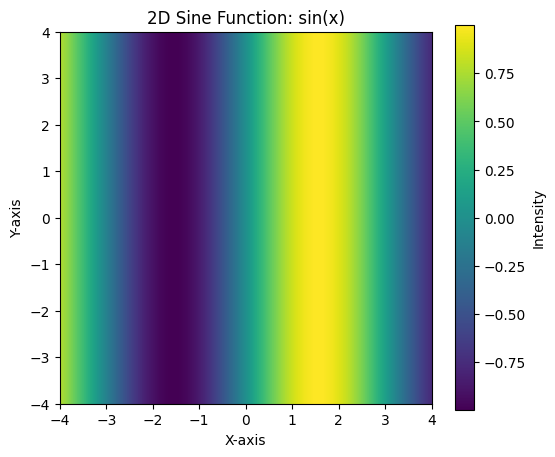

Using: cpu


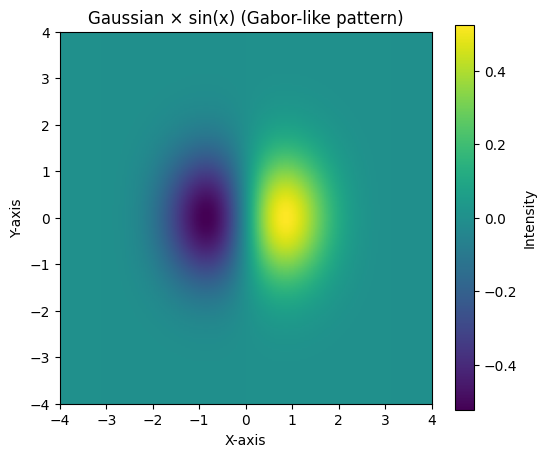

In [16]:
import torch
import matplotlib.pyplot as plt

# Device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

# Define grid
x = torch.linspace(-4, 4, 200, device=device)
y = torch.linspace(-4, 4, 200, device=device)
Y, X = torch.meshgrid(y, x, indexing='ij')  # shape: [200, 200]

# Simple sine function (sin(x))
Z = torch.sin(X)

# Plot (convert to CPU numpy for matplotlib)
plt.figure(figsize=(6,5))
plt.imshow(Z.detach().cpu().numpy(), extent=(-4,4,-4,4), origin='lower', cmap='viridis')
plt.colorbar(label="Intensity")
plt.title("2D Sine Function: sin(x)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

#gabor filter
import torch
import matplotlib.pyplot as plt

# Device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

# Grid
x = torch.linspace(-4, 4, 200, device=device)
y = torch.linspace(-4, 4, 200, device=device)
Y, X = torch.meshgrid(y, x, indexing='ij')

# Components
sigma = 1.0
gaussian = torch.exp(- (X**2 + Y**2) / (2 * sigma**2))   # Gaussian
sine_x   = torch.sin(X)                                   # sin(x)

# Modulation (Gaussian × sine)
Z = gaussian * sine_x

# Plot
plt.figure(figsize=(6,5))
plt.imshow(Z.detach().cpu().numpy(), extent=(-4,4,-4,4), origin='lower', cmap='viridis')
plt.colorbar(label="Intensity")
plt.title("Gaussian × sin(x) (Gabor-like pattern)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()



# **TASK 2.1**

/tmp/ipython-input-3917446728.py:35: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np.uint8(np.clip(a, 0, 255))


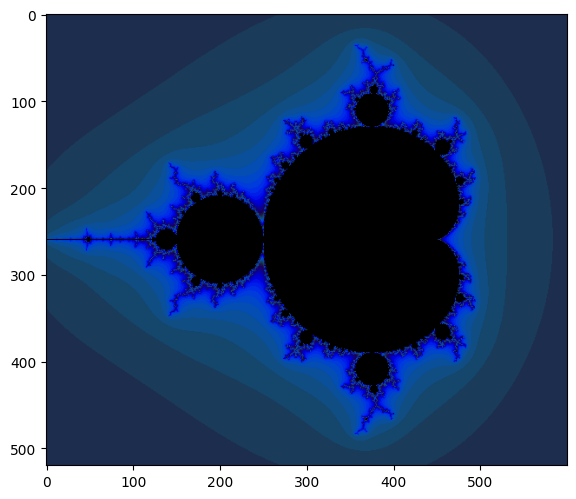

In [19]:
# Use NumPy to create a 2D array of complex numbers on [-2,2]x[-2,2]
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y) #important!
zs = z.clone() #Updated!
ns = torch.zeros_like(z)

# transfer to the GPU device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

#Mandelbrot Set
for i in range(200):
#Compute the new values of z: z^2 + x
  zs_= zs*zs + z
  #Have we diverged with this new value?
  not_diverged = torch.abs(zs_) < 4.0
  #Update variables to compute
  ns += not_diverged
  zs = zs_

def processFractal(a):
  """Display an array of iteration counts as a
  colorful picture of a fractal."""
  a_cyclic = (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate([10+20*np.cos(a_cyclic),
  30+50*np.sin(a_cyclic),
  155-80*np.cos(a_cyclic)], 2)
  img[a==a.max()] = 0
  a = img
  a = np.uint8(np.clip(a, 0, 255))
  return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

# **TASK 2.2**

CUDA available: False

Config {'width': 1200, 'height': 800, 'max_iter': 200}:
  CPU time: 3.296s
  CPU time: 2.292s

Config {'width': 2400, 'height': 1600, 'max_iter': 400}:
  CPU time: 27.655s
  CPU time: 25.981s


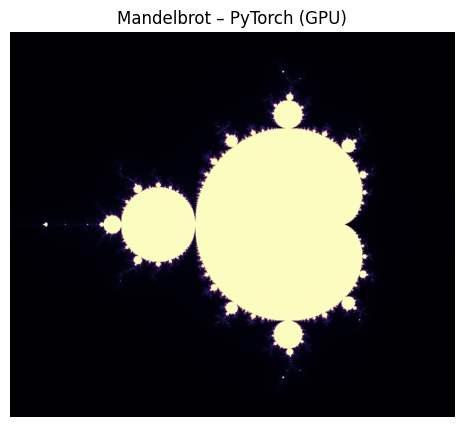

In [20]:
#code generated by ai for generating the mandelbrot set
#prompt used: Include benchmarking for cpu and gpu, generate the mandlebrot set implemented in pytorch that runs on gpu.
#reflection: 1) AI produced a correct vectorized PyTorch version that rendered the Mandelbrot without per-pixel loops. 2) numpy arrays run on cpu only, tensors can run on gpu and cpu.

import torch, time
import matplotlib.pyplot as plt

def mandelbrot_torch(width=2000, height=1200, max_iter=300, xlim=(-2.0, 1.0), ylim=(-1.3, 1.3), device='cpu'):
    device = torch.device(device)
    dtype = torch.complex64  # faster on GPU than complex128
    # Grid
    xs = torch.linspace(xlim[0], xlim[1], width, device=device)
    ys = torch.linspace(ylim[0], ylim[1], height, device=device)
    Y, X = torch.meshgrid(ys, xs, indexing='ij')
    C = X.to(torch.float32) + 1j * Y.to(torch.float32)
    Z = torch.zeros_like(C, dtype=dtype)
    C = C.to(dtype)

    # Iterations (vectorized)
    escaped = torch.zeros((height, width), dtype=torch.bool, device=device)
    counts  = torch.zeros((height, width), dtype=torch.int16, device=device)

    for i in range(max_iter):
        Z = Z*Z + C
        mag2 = (Z.real*Z.real + Z.imag*Z.imag)  # faster than torch.abs(Z)**2
        just_escaped = (mag2 > 4.0) & (~escaped)
        counts[~escaped] = i  # record iteration when still inside; optional: counts[just_escaped] = i
        escaped |= just_escaped
        # Optional early stop if everything escaped:
        if escaped.all():
            break

    return counts

def time_run(device, **kw):
    # Warmup
    _ = mandelbrot_torch(device=device, **kw)
    if 'cuda' in str(device):
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = mandelbrot_torch(device=device, **kw)
    if 'cuda' in str(device):
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    return t1 - t0

cfgs = [
    dict(width=1200, height=800, max_iter=200),
    dict(width=2400, height=1600, max_iter=400),
]

print("CUDA available:", torch.cuda.is_available())
gpu = 'cuda' if torch.cuda.is_available() else 'cpu'

for cfg in cfgs:
    tcpu = time_run('cpu', **cfg)
    tgpu = time_run(gpu, **cfg)
    print(f"\nConfig {cfg}:")
    print(f"  CPU time: {tcpu:.3f}s")
    print(f"  {gpu.upper()} time: {tgpu:.3f}s")

# Example render for your report
counts = mandelbrot_torch(width=1600, height=1000, max_iter=300, device=gpu)
img = counts.detach().cpu().numpy()
plt.figure(figsize=(8,5))
plt.imshow(img, cmap='magma', origin='lower', extent=(-2.0,1.0,-1.3,1.3))
plt.title("Mandelbrot – PyTorch (GPU)")
plt.axis('off')
plt.show()


# **TASK 2.3 (DEMO)**

Using device: cpu


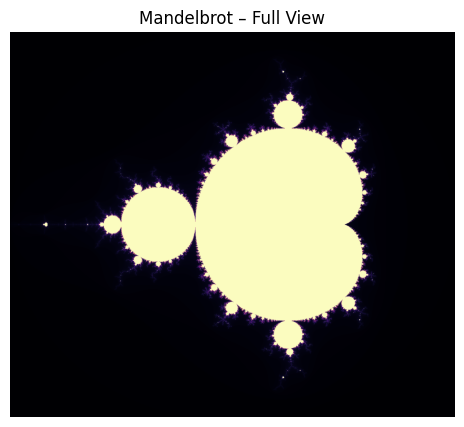

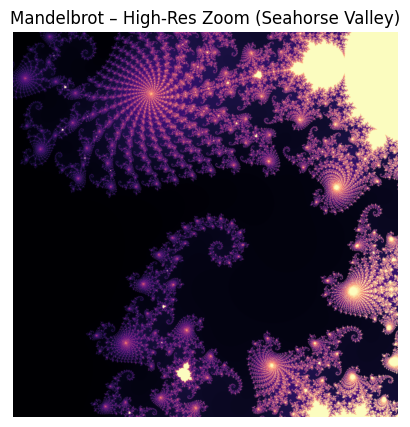

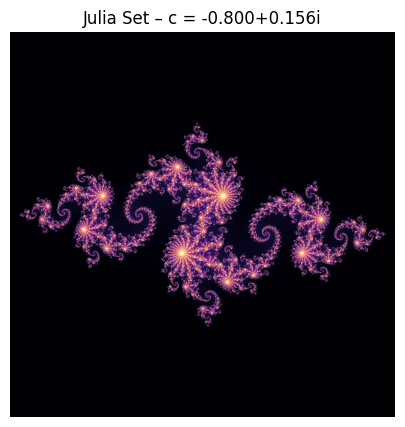

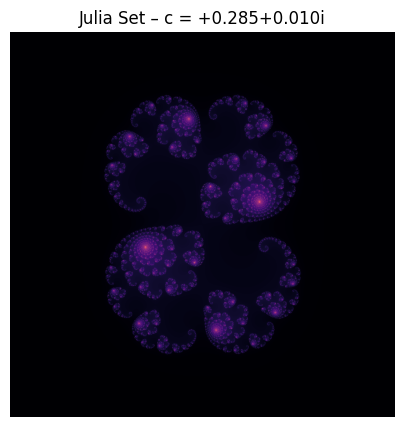

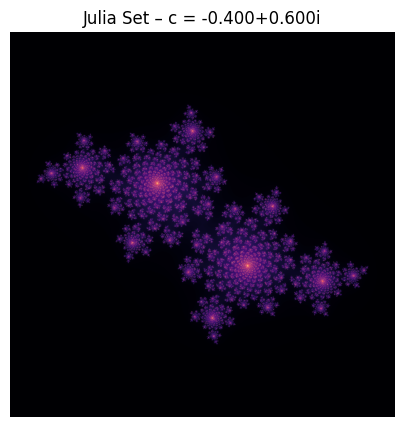

In [21]:
import torch
import matplotlib.pyplot as plt

# ===== Device setup (GPU if available) =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ===== Helpers =====
def complex_grid(xmin, xmax, ymin, ymax, width, height, device, dtype=torch.complex64):
    xs = torch.linspace(xmin, xmax, width, device=device)
    ys = torch.linspace(ymin, ymax, height, device=device)
    Y, X = torch.meshgrid(ys, xs, indexing='ij')
    return (X.to(torch.float32) + 1j * Y.to(torch.float32)).to(dtype)

@torch.inference_mode()
def mandelbrot_counts(width=1600, height=1000, max_iter=300,
                      xmin=-2.0, xmax=1.0, ymin=-1.3, ymax=1.3,
                      device=device):
    C = complex_grid(xmin, xmax, ymin, ymax, width, height, device)
    Z = torch.zeros_like(C)
    iters  = torch.zeros((height, width), dtype=torch.int16, device=device)
    escaped = torch.zeros((height, width), dtype=torch.bool, device=device)

    for i in range(max_iter):
        Z = Z*Z + C
        mag2 = Z.real*Z.real + Z.imag*Z.imag
        newly = (mag2 > 4.0) & (~escaped)
        iters[newly] = i
        escaped |= newly
        if escaped.all():
            break

    # Unescaped points get max_iter (for cleaner coloring)
    iters[~escaped] = max_iter
    return iters

@torch.inference_mode()
def julia_counts(c, width=1600, height=1000, max_iter=300,
                 xmin=-1.6, xmax=1.6, ymin=-1.6, ymax=1.6,
                 device=device):
    Z = complex_grid(xmin, xmax, ymin, ymax, width, height, device)
    c = torch.tensor(complex(c), dtype=torch.complex64, device=device)
    iters  = torch.zeros((height, width), dtype=torch.int16, device=device)
    escaped = torch.zeros((height, width), dtype=torch.bool, device=device)

    for i in range(max_iter):
        Z = Z*Z + c
        mag2 = Z.real*Z.real + Z.imag*Z.imag
        newly = (mag2 > 4.0) & (~escaped)
        iters[newly] = i
        escaped |= newly
        if escaped.all():
            break

    iters[~escaped] = max_iter
    return iters

def show_img(counts, extent, title):
    img = counts.detach().cpu().numpy()
    plt.figure(figsize=(8,5))
    plt.imshow(img, cmap='magma', origin='lower', extent=extent)
    plt.title(title)
    plt.axis('off')
    plt.show()

# ===== (1) High-res Mandelbrot zoom =====
# Full view (baseline)
counts_full = mandelbrot_counts(width=1600, height=1000, max_iter=300,
                                xmin=-2.0, xmax=1.0, ymin=-1.3, ymax=1.3)
show_img(counts_full, (-2.0, 1.0, -1.3, 1.3), "Mandelbrot – Full View")

# Zoomed view around “Seahorse Valley” (classic interesting region)
cx, cy = -0.743643887037151, 0.131825904205330   # center
half_w = 0.005                                    # shrink this for deeper zooms
xmin, xmax = cx - half_w, cx + half_w
ymin, ymax = cy - half_w, cy + half_w

counts_zoom = mandelbrot_counts(width=2400, height=1600, max_iter=800,
                                xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax)
show_img(counts_zoom, (xmin, xmax, ymin, ymax), "Mandelbrot – High-Res Zoom (Seahorse Valley)")

# ===== (2) Julia sets for a few c values =====
for c in [-0.8 + 0.156j, 0.285 + 0.01j, -0.4 + 0.6j]:
    counts_j = julia_counts(c=c, width=1600, height=1000, max_iter=400,
                            xmin=-1.6, xmax=1.6, ymin=-1.6, ymax=1.6)
    show_img(counts_j, (-1.6, 1.6, -1.6, 1.6), f"Julia Set – c = {c.real:+.3f}{c.imag:+.3f}i")
